# Simulation analysis

After autorunning the simulation several times,\
with different input values, lets analyze\
values, error and how reliable it really is

In [17]:
from datetime import datetime, timedelta # For days_between function
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astropy.time import Time
import lsst.summit.utils.butlerUtils as butlerUtils
from lsst.summit.utils.dateTime import (getDayObsEndTime, getDayObsStartTime)
from lsst.summit.utils.efdUtils import (getEfdData, makeEfdClient)

# Create the client for InfluxQL
efd_client = makeEfdClient()
butler = butlerUtils.makeDefaultButler("LSSTCam", embargo=False)

### Autorun settings

In [30]:
def timestamp_to_utc(timestamp):
    """
    Takes the timestamp in string value and
    converts it to a query readable timestamp
    
    Parameter
    ---------
    Timestamp: string (YYYY-MM-DD hh:mm:ss.ms)

    Returns:
    --------
    EFD-readable timestamp
    """
    timestamp = pd.to_datetime(str(timestamp))
    new_stamp = timestamp.value
    step = int(0.01 * 1e10)
    rounded_stamp = (new_stamp // step) * step
    timestamp = Time(pd.to_datetime(rounded_stamp), scale="utc")

    return timestamp


def days_between(start, end):
    """
    Creates a list of YYYYMMDD days for analysis
    
    Parameters:
    -----------
    start : int (YYYYMMDD)
        Start date
    end : int (YYYYMMDD)
        End date
    
    Returns:
    --------
    List with YYYYMMDD in between dates given
    """
    start_date = datetime.strptime(str(start), "%Y%m%d")
    end_date = datetime.strptime(str(end), "%Y%m%d")
    
    days = []
    current = start_date
    while current <= end_date:
        days.append(int(current.strftime("%Y%m%d")))
        current += timedelta(days=1)
    
    return days


day_start = 20260509
day_end   = 20260509

daysinbetween = days_between(day_start, day_end)
print(f"We have {len(daysinbetween)} days to analyze")

start_time = getDayObsStartTime(day_start)
end_time   = getDayObsEndTime(day_end)

start_time = timestamp_to_utc(start_time)
end_time   = timestamp_to_utc(end_time)

topic   = 'lsst.sal.ESS.logevent_ringssMeasurement'
columns = ['fwhmFree', 'fwhmScintillation', 
            'fwhmSector', 'wind', 'flux']

df = getEfdData(
    client  = efd_client,
    topic   = str(topic),
    columns = columns,
    begin   = start_time,
    end     = end_time,
                )

df

We have 1 days to analyze


,fwhmFree,fwhmScintillation,fwhmSector,wind,flux
2026-05-09 22:33:45.874859+00:00,1.328,1.490,1.889,6.71,54131
2026-05-09 22:34:15.901868+00:00,1.165,1.272,1.721,7.51,52584
2026-05-09 22:34:55.934843+00:00,1.398,1.658,2.071,7.60,52832
2026-05-09 22:35:35.966923+00:00,1.392,1.629,2.083,8.13,52880
2026-05-09 22:36:16.005291+00:00,1.342,1.600,2.045,8.19,52768
...,...,...,...,...,...
2026-05-10 10:46:03.798030+00:00,0.418,0.896,0.938,7.66,66189
2026-05-10 10:46:33.823020+00:00,0.366,0.888,0.909,8.14,65922
2026-05-10 10:47:03.848987+00:00,0.367,0.879,0.874,8.06,66375
2026-05-10 10:47:43.883305+00:00,0.409,0.863,0.907,7.70,66767


### Analysis

In [2]:
df = pd.read_csv('testsimul_results.csv')
print(f'{len(df)} runs, {df.shape[1]} columns')
df.head()

243 runs, 127 columns


,iso_time,input_seeing_arcsec,input_wind_ms,input_zlow_m,input_zhigh_m,input_highfrac,input_starmag,input_gain,input_seed0,input_ngrid,...,cov_m_13,cov_m_14,cov_m_15,cov_m_16,cov_m_17,cov_m_18,cov_m_19,cov_m_20,coef_ncoef,coef_nframes
0,2026-10-02T16:21:37Z,1.0,10.0,500,10500,0.1,2,0,52403,512,...,0.000191,0.000141,0.000073,0.000048,0.000006,-0.000017,-2.731040e-05,-0.000018,58,1000
1,2026-10-02T16:26:52Z,0.4,2.0,500,10500,0.1,2,0,281214179,512,...,0.000044,0.000028,0.000011,0.000005,0.000003,0.000001,1.254242e-06,0.000002,58,1000
2,2026-10-02T16:28:27Z,0.5,20.0,500,10500,0.1,2,0,1576357693,512,...,0.000061,0.000043,0.000012,0.000005,0.000006,0.000004,-1.904644e-07,-0.000002,58,1000
3,2026-10-02T16:30:01Z,0.6,8.0,500,10500,0.1,2,0,2063658284,512,...,0.000084,0.000054,0.000037,0.000020,0.000010,0.000003,-2.475019e-06,-0.000004,58,1000
4,2026-10-02T16:31:37Z,0.7,17.0,500,10500,0.1,2,0,2840956263,512,...,0.000128,0.000074,0.000037,0.000020,-0.000003,-0.000007,-1.064411e-05,-0.000011,58,1000


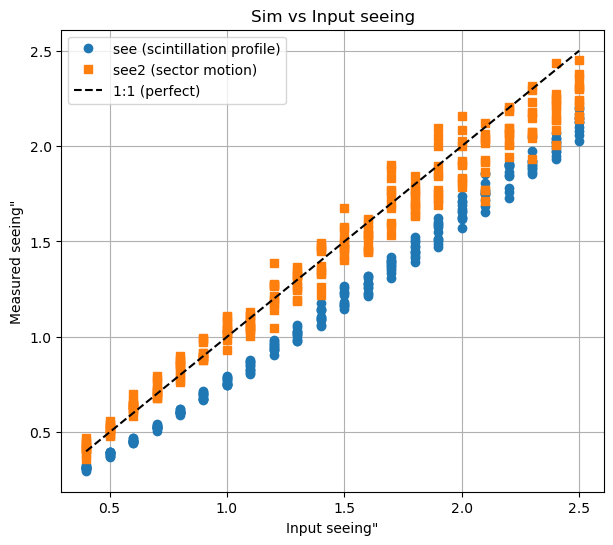

In [3]:
# Measured seeing vs. input seeing. Columns are accessed by name as
# df['col'] (a Series you can pass straight to matplotlib).
plt.figure(figsize=(7, 6))
plt.plot(df['input_seeing_arcsec'], df['see_arcsec'],  'o', label='see (scintillation profile)')
plt.plot(df['input_seeing_arcsec'], df['see2_arcsec'], 's', label='see2 (sector motion)')

lims = [df['input_seeing_arcsec'].min(), df['input_seeing_arcsec'].max()]
plt.plot(lims, lims, 'k--', label='1:1 (perfect)')

plt.xlabel('Input seeing"')
plt.ylabel('Measured seeing"')
plt.title('Sim vs Input seeing')
plt.legend()
plt.grid(True)
plt.show()

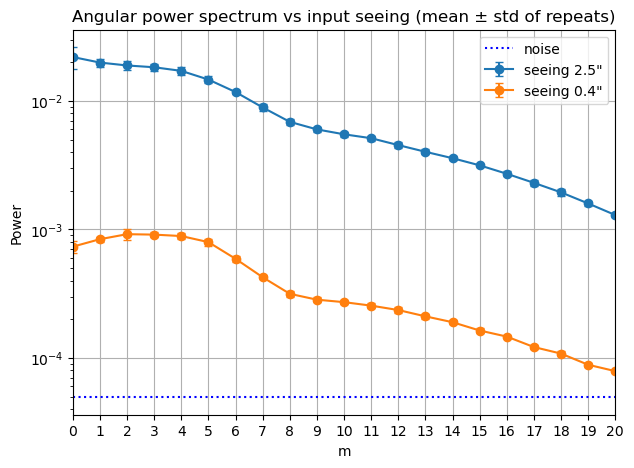

In [4]:
# Angular power spectrum (same plot as d_statmom / d_testsimul), now
# overlaying several input-seeing conditions with error bars.
# The sweep repeats each input seeing a few times, so for every seeing we
# average the repeats per angular mode m and use their spread as the error.
m = np.arange(21)                                   # angular frequency axis (0..mmax)
power_cols = [f'power_m_{j}' for j in m]

# mean and std of each power_m across the repeated runs at each input seeing
grp  = df.groupby('input_seeing_arcsec')[power_cols]
mean = grp.mean()
std  = grp.std().fillna(0.0)                        # 0 if a seeing has a single run

# pick a few seeing values spanning the range (edit as desired)
seeing = sorted(df['input_seeing_arcsec'].unique())
selected = [seeing[-1], seeing[0]]

plt.figure(figsize=(7, 5))
for s in selected:
    y   = mean.loc[s].to_numpy(dtype=float)
    err = std.loc[s].to_numpy(dtype=float)
    plt.errorbar(m, np.maximum(y, 1e-12), yerr=err, marker='o', capsize=3,
                 label=f'seeing {s}\"')

# shared noise floor (mean anoise over all runs)
plt.axhline(max(float(df['anoise'].mean()), 1e-12), ls=':', color='b', label='noise')
plt.yscale('log')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 1))
plt.xlabel('m')
plt.ylabel('Power')
plt.title('Angular power spectrum vs input seeing (mean \u00b1 std of repeats)')
plt.legend()
plt.grid(True)
plt.show()
